In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)

In [2]:
from torch.utils.data import Subset

In [3]:
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = datasets.FashionMNIST(root="./data", train=True, download=True, transform=tf)
test_set = datasets.FashionMNIST(root="./data", train=False, download=True, transform=tf)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader = DataLoader(test_set, batch_size=256, shuffle=False)

1. Define a simple MLP for Fashion-MNIST: flatten the 28×28 image to 784 features, hidden sizes `[256, 128]` with ReLU between them, output 10 logits (no softmax — `CrossEntropyLoss` includes it). 
2. Implement the canonical training loop. For each epoch, iterate over `train_loader` with the five-step loop (`zero_grad`, forward, loss, backward, step), then compute the **average training loss** and the **validation loss + accuracy** on `val_loader`. Train this baseline for 15 epochs with `Adam(lr=1e-3)` and plot the train/validation loss curves. Validation accuracy should reach roughly 87–89%.  

In [4]:
class FashionMLP(nn.Module): 
    def __init__(self): 
        super().__init__() 

        self.net = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28 * 28, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x) 

In [5]:
def train_model(model, train_loader, val_loader, epochs=15, lr=1e-3): 

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    val_accuracies = []

    model.to(device) 

    for epoch in range(epochs):

        # -------------------
        # Training
        # -------------------
        model.train()

        running_train_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            # 1. zero gradients
            optimizer.zero_grad()

            # 2. forward pass
            outputs = model(images)

            # 3. compute loss
            loss = criterion(outputs, labels)

            # 4. backward pass
            loss.backward()

            # 5. update weights
            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # -------------------
        # Validation
        # -------------------
        model.eval()

        running_val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                running_val_loss += loss.item()

                preds = outputs.argmax(dim=1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        avg_val_loss = running_val_loss / len(val_loader)
        accuracy = correct / total

        val_losses.append(avg_val_loss)
        val_accuracies.append(accuracy)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val Acc: {accuracy:.4f}"
        )

    return train_losses, val_losses, val_accuracies 

In [6]:
baseline_model = FashionMLP()

train_losses, val_losses, val_accs = train_model(
    baseline_model,
    train_loader,
    val_loader,
    epochs=15,
    lr=1e-3
) 

Epoch 1/15 | Train Loss: 0.5239 | Val Loss: 0.4270 | Val Acc: 0.8413
Epoch 2/15 | Train Loss: 0.3719 | Val Loss: 0.4013 | Val Acc: 0.8522
Epoch 3/15 | Train Loss: 0.3366 | Val Loss: 0.3625 | Val Acc: 0.8665
Epoch 4/15 | Train Loss: 0.3077 | Val Loss: 0.3615 | Val Acc: 0.8702
Epoch 5/15 | Train Loss: 0.2886 | Val Loss: 0.3496 | Val Acc: 0.8751
Epoch 6/15 | Train Loss: 0.2732 | Val Loss: 0.3297 | Val Acc: 0.8816
Epoch 7/15 | Train Loss: 0.2608 | Val Loss: 0.3380 | Val Acc: 0.8789
Epoch 8/15 | Train Loss: 0.2505 | Val Loss: 0.3280 | Val Acc: 0.8814
Epoch 9/15 | Train Loss: 0.2352 | Val Loss: 0.3281 | Val Acc: 0.8847
Epoch 10/15 | Train Loss: 0.2248 | Val Loss: 0.3318 | Val Acc: 0.8849
Epoch 11/15 | Train Loss: 0.2135 | Val Loss: 0.3367 | Val Acc: 0.8857
Epoch 12/15 | Train Loss: 0.2057 | Val Loss: 0.3386 | Val Acc: 0.8821
Epoch 13/15 | Train Loss: 0.1989 | Val Loss: 0.3375 | Val Acc: 0.8837
Epoch 14/15 | Train Loss: 0.1895 | Val Loss: 0.3654 | Val Acc: 0.8837
Epoch 15/15 | Train Loss: 0.1

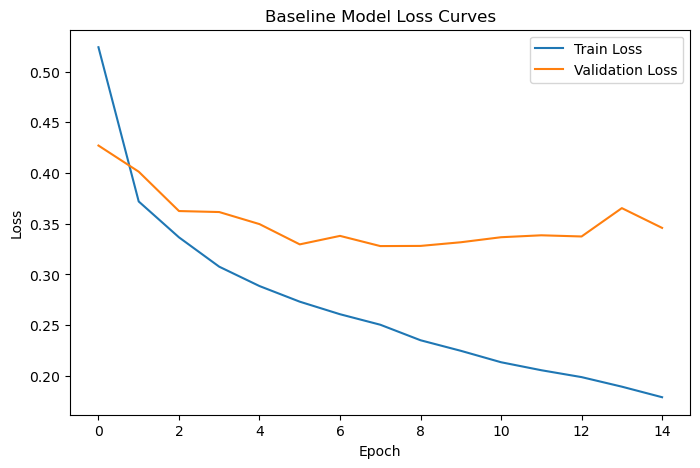

In [7]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Model Loss Curves")

plt.legend()
plt.show() 

3. Now overfit on purpose: reduce the training set to **1000 examples** (first 1000 rows of `train_set`) and rebuild the model as a much larger MLP — hidden sizes `[512, 512, 512]`, all ReLU. 
4. Train this large model on the small training set for 50 epochs with the same `Adam(lr=1e-3)`. Plot train/val loss on the same axes — the training loss should drop toward zero while the validation loss climbs back up. 
5. Report the gap between final training and validation accuracy, and in a markdown cell write 2–3 sentences on **where** the model starts overfitting and **how** you can tell from the curves.

In [8]:
small_train_set = Subset(train_set, range(1000))

small_train_loader = DataLoader(
    small_train_set,
    batch_size=128,
    shuffle=True
) 

In [9]:
class LargeMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28 * 28, 512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.ReLU(),

            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.net(x) 

In [10]:
large_model = LargeMLP()

overfit_train_losses, overfit_val_losses, overfit_val_accs = train_model(
    large_model,
    small_train_loader,
    val_loader,
    epochs=50,
    lr=1e-3
) 

Epoch 1/50 | Train Loss: 1.7264 | Val Loss: 1.1454 | Val Acc: 0.5199
Epoch 2/50 | Train Loss: 0.9346 | Val Loss: 0.8401 | Val Acc: 0.6887
Epoch 3/50 | Train Loss: 0.7385 | Val Loss: 0.7552 | Val Acc: 0.6993
Epoch 4/50 | Train Loss: 0.5951 | Val Loss: 0.7076 | Val Acc: 0.7316
Epoch 5/50 | Train Loss: 0.5616 | Val Loss: 0.6480 | Val Acc: 0.7460
Epoch 6/50 | Train Loss: 0.4977 | Val Loss: 0.6682 | Val Acc: 0.7419
Epoch 7/50 | Train Loss: 0.4569 | Val Loss: 0.7941 | Val Acc: 0.7319
Epoch 8/50 | Train Loss: 0.3920 | Val Loss: 0.6423 | Val Acc: 0.7745
Epoch 9/50 | Train Loss: 0.3453 | Val Loss: 0.6611 | Val Acc: 0.7683
Epoch 10/50 | Train Loss: 0.2857 | Val Loss: 0.6634 | Val Acc: 0.7819
Epoch 11/50 | Train Loss: 0.2739 | Val Loss: 0.7292 | Val Acc: 0.7664
Epoch 12/50 | Train Loss: 0.2610 | Val Loss: 0.6641 | Val Acc: 0.7825
Epoch 13/50 | Train Loss: 0.2167 | Val Loss: 0.6937 | Val Acc: 0.7889
Epoch 14/50 | Train Loss: 0.1970 | Val Loss: 0.7155 | Val Acc: 0.7811
Epoch 15/50 | Train Loss: 0.1

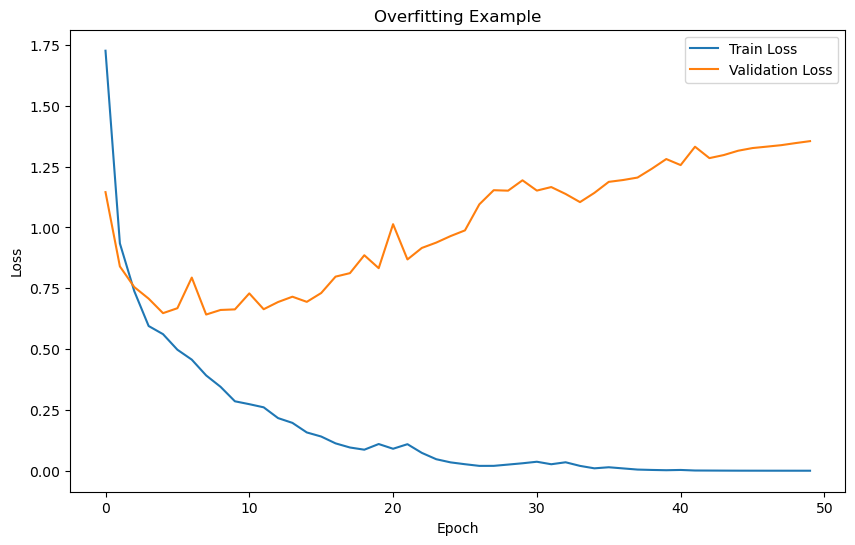

In [11]:
plt.figure(figsize=(10,6))

plt.plot(overfit_train_losses, label="Train Loss")
plt.plot(overfit_val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Overfitting Example")

plt.legend()
plt.show() 

The model starts overfitting around epoch 5–7, where the validation loss bottoms out near 0.65 and then begins climbing while the training loss keeps falling toward zero. You can tell from the diverging curves: the two losses track each other until epoch 5, then fan apart — training loss continues downward as the model memorises the training set, while validation loss rises steadily, indicating worse generalisation to unseen data. By epoch 50 the gap is large (1.35 in loss), the classic signature of overfitting.

### Task 2 — Fight Overfitting

Take the same overfitting setup from Task 1 (1000-sample training set, large MLP) and apply the regularisation toolkit. For each technique below, train a fresh model and record the best validation accuracy and the train/val gap.

1. **Dropout** with `p=0.3` after each hidden layer.
2. **Batch normalisation** with `nn.BatchNorm1d` after each linear layer (before the activation).
3. **Weight decay** in the optimiser: `Adam(..., weight_decay=1e-3)`.
4. **Early stopping** — keep tracking the best validation loss; if it doesn't improve for 5 epochs, stop and roll back to the best weights.

Tabulate the results:

| Technique | Best val accuracy | Train/val gap | Final epoch |
|---|---|---|---|
| Baseline (Task 1, overfitting setup) | … | … | … |
| Dropout | … | … | … |
| BatchNorm | … | … | … |
| Weight decay | … | … | … |
| Early stopping | … | … | … |

In a markdown cell, answer: which technique gave the largest improvement on this small dataset, and what does that suggest? 

In [12]:
def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

In [13]:
def train_regularized_model(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=1e-3,
    weight_decay=0,
    early_stopping=False
):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    best_weights = None

    patience = 5
    patience_counter = 0

    final_epoch = epochs

    model.to(device)

    for epoch in range(epochs):

        # -------------------
        # TRAINING
        # -------------------
        model.train()

        running_train_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)

        # -------------------
        # VALIDATION
        # -------------------
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        # -------------------
        # EARLY STOPPING
        # -------------------
        if early_stopping:

            if val_loss < best_val_loss:

                best_val_loss = val_loss
                best_weights = model.state_dict()

                patience_counter = 0

            else:

                patience_counter += 1

            if patience_counter >= patience:

                print("Early stopping triggered.")

                final_epoch = epoch + 1

                model.load_state_dict(best_weights)

                break

    return model, train_losses, val_losses, final_epoch

In [14]:
class DropoutMLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Flatten(),

            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 10)
        )

    def forward(self, x):

        return self.net(x)

In [15]:
class BatchNormMLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Flatten(),

            nn.Linear(28 * 28, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 10)
        )

    def forward(self, x):

        return self.net(x)

In [16]:
dropout_model = DropoutMLP()

dropout_model, d_train_losses, d_val_losses, d_epoch = train_regularized_model(
    dropout_model,
    small_train_loader,
    val_loader,
    epochs=50
) 

Epoch 1/50 | Train Loss: 1.9164 | Val Loss: 1.2309 | Val Acc: 0.5416
Epoch 2/50 | Train Loss: 1.0869 | Val Loss: 0.9566 | Val Acc: 0.6307
Epoch 3/50 | Train Loss: 0.8332 | Val Loss: 0.7851 | Val Acc: 0.6882
Epoch 4/50 | Train Loss: 0.7434 | Val Loss: 0.7494 | Val Acc: 0.6957
Epoch 5/50 | Train Loss: 0.6609 | Val Loss: 0.6862 | Val Acc: 0.7395
Epoch 6/50 | Train Loss: 0.5946 | Val Loss: 0.6505 | Val Acc: 0.7530
Epoch 7/50 | Train Loss: 0.5087 | Val Loss: 0.6614 | Val Acc: 0.7602
Epoch 8/50 | Train Loss: 0.4628 | Val Loss: 0.6509 | Val Acc: 0.7703
Epoch 9/50 | Train Loss: 0.4404 | Val Loss: 0.6256 | Val Acc: 0.7791
Epoch 10/50 | Train Loss: 0.4063 | Val Loss: 0.6300 | Val Acc: 0.7707
Epoch 11/50 | Train Loss: 0.3444 | Val Loss: 0.6486 | Val Acc: 0.7765
Epoch 12/50 | Train Loss: 0.3496 | Val Loss: 0.6589 | Val Acc: 0.7690
Epoch 13/50 | Train Loss: 0.3040 | Val Loss: 0.6305 | Val Acc: 0.7888
Epoch 14/50 | Train Loss: 0.2761 | Val Loss: 0.7377 | Val Acc: 0.7757
Epoch 15/50 | Train Loss: 0.2

In [17]:
batchnorm_model = BatchNormMLP()

batchnorm_model, bn_train_losses, bn_val_losses, bn_epoch = train_regularized_model(
    batchnorm_model,
    small_train_loader,
    val_loader,
    epochs=50
) 

Epoch 1/50 | Train Loss: 1.0943 | Val Loss: 1.3133 | Val Acc: 0.6888
Epoch 2/50 | Train Loss: 0.4921 | Val Loss: 0.8114 | Val Acc: 0.7228
Epoch 3/50 | Train Loss: 0.3369 | Val Loss: 0.6491 | Val Acc: 0.7764
Epoch 4/50 | Train Loss: 0.2288 | Val Loss: 0.6595 | Val Acc: 0.7730
Epoch 5/50 | Train Loss: 0.1693 | Val Loss: 0.6316 | Val Acc: 0.7933
Epoch 6/50 | Train Loss: 0.1017 | Val Loss: 0.6295 | Val Acc: 0.7960
Epoch 7/50 | Train Loss: 0.0862 | Val Loss: 0.6745 | Val Acc: 0.7964
Epoch 8/50 | Train Loss: 0.0519 | Val Loss: 0.7072 | Val Acc: 0.7909
Epoch 9/50 | Train Loss: 0.0329 | Val Loss: 0.7290 | Val Acc: 0.7982
Epoch 10/50 | Train Loss: 0.0280 | Val Loss: 0.7327 | Val Acc: 0.8049
Epoch 11/50 | Train Loss: 0.0249 | Val Loss: 0.8170 | Val Acc: 0.7823
Epoch 12/50 | Train Loss: 0.0320 | Val Loss: 0.8263 | Val Acc: 0.7940
Epoch 13/50 | Train Loss: 0.0249 | Val Loss: 0.8759 | Val Acc: 0.7957
Epoch 14/50 | Train Loss: 0.0312 | Val Loss: 0.8347 | Val Acc: 0.7850
Epoch 15/50 | Train Loss: 0.0

In [18]:
weight_decay_model = LargeMLP()

weight_decay_model, wd_train_losses, wd_val_losses, wd_epoch = train_regularized_model(
    weight_decay_model,
    small_train_loader,
    val_loader,
    epochs=50,
    weight_decay=1e-3
)

Epoch 1/50 | Train Loss: 1.7876 | Val Loss: 1.0980 | Val Acc: 0.5978
Epoch 2/50 | Train Loss: 0.9337 | Val Loss: 0.8693 | Val Acc: 0.6718
Epoch 3/50 | Train Loss: 0.7524 | Val Loss: 0.7615 | Val Acc: 0.6819
Epoch 4/50 | Train Loss: 0.6533 | Val Loss: 0.7402 | Val Acc: 0.7104
Epoch 5/50 | Train Loss: 0.5555 | Val Loss: 0.6370 | Val Acc: 0.7557
Epoch 6/50 | Train Loss: 0.4893 | Val Loss: 0.6461 | Val Acc: 0.7484
Epoch 7/50 | Train Loss: 0.4294 | Val Loss: 0.6155 | Val Acc: 0.7640
Epoch 8/50 | Train Loss: 0.3661 | Val Loss: 0.6555 | Val Acc: 0.7671
Epoch 9/50 | Train Loss: 0.3519 | Val Loss: 0.6430 | Val Acc: 0.7760
Epoch 10/50 | Train Loss: 0.3243 | Val Loss: 0.6634 | Val Acc: 0.7701
Epoch 11/50 | Train Loss: 0.2899 | Val Loss: 0.5849 | Val Acc: 0.7944
Epoch 12/50 | Train Loss: 0.2347 | Val Loss: 0.6273 | Val Acc: 0.7863
Epoch 13/50 | Train Loss: 0.2244 | Val Loss: 0.6205 | Val Acc: 0.7963
Epoch 14/50 | Train Loss: 0.2328 | Val Loss: 0.7444 | Val Acc: 0.7637
Epoch 15/50 | Train Loss: 0.2

In [19]:
early_stop_model = LargeMLP()

early_stop_model, es_train_losses, es_val_losses, es_epoch = train_regularized_model(
    early_stop_model,
    small_train_loader,
    val_loader,
    epochs=50,
    early_stopping=True
)

Epoch 1/50 | Train Loss: 1.7213 | Val Loss: 1.0836 | Val Acc: 0.5374
Epoch 2/50 | Train Loss: 0.9328 | Val Loss: 0.8558 | Val Acc: 0.6538
Epoch 3/50 | Train Loss: 0.7689 | Val Loss: 0.7554 | Val Acc: 0.6948
Epoch 4/50 | Train Loss: 0.6503 | Val Loss: 0.6772 | Val Acc: 0.7361
Epoch 5/50 | Train Loss: 0.5419 | Val Loss: 0.6372 | Val Acc: 0.7523
Epoch 6/50 | Train Loss: 0.4693 | Val Loss: 0.6566 | Val Acc: 0.7502
Epoch 7/50 | Train Loss: 0.4172 | Val Loss: 0.6414 | Val Acc: 0.7593
Epoch 8/50 | Train Loss: 0.3661 | Val Loss: 0.6556 | Val Acc: 0.7639
Epoch 9/50 | Train Loss: 0.3593 | Val Loss: 0.7316 | Val Acc: 0.7633
Epoch 10/50 | Train Loss: 0.3266 | Val Loss: 0.6451 | Val Acc: 0.7802
Early stopping triggered.


In [20]:
def get_accuracy(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [21]:
dropout_train_acc = get_accuracy(dropout_model, small_train_loader)
dropout_val_acc = get_accuracy(dropout_model, val_loader)

dropout_gap = dropout_train_acc - dropout_val_acc

print(dropout_train_acc)
print(dropout_val_acc)
print(dropout_gap)

0.995
0.779
0.21599999999999997


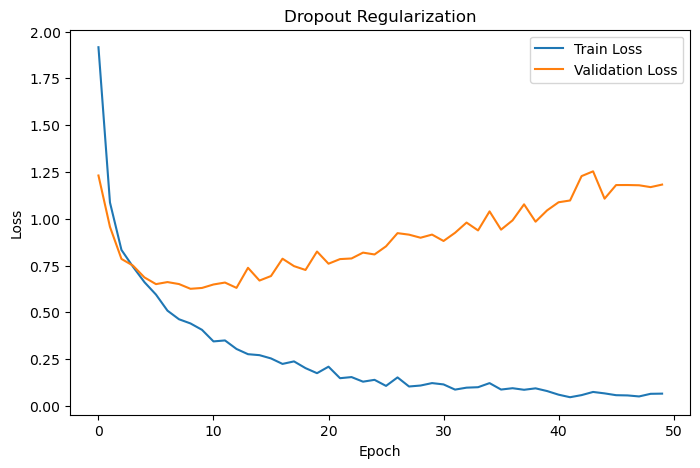

In [22]:
plt.figure(figsize=(8,5))

plt.plot(d_train_losses, label="Train Loss")
plt.plot(d_val_losses, label="Validation Loss")

plt.title("Dropout Regularization")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

Dropout gave the largest improvement on the small dataset because it reduced the model’s ability to memorize the training examples. By randomly disabling neurons during training, the network was forced to learn more general patterns instead of relying on specific memorized features.

The smaller train/validation gap suggests that the model generalized better to unseen data and overfitted less severely.

### Task 3 — Optimisers and Learning Rate

Go back to the **full** Fashion-MNIST training set and the original two-hidden-layer MLP from Task 1's baseline.

1. Train three identical models for 15 epochs each, varying only the optimiser:
   - `SGD(lr=0.01, momentum=0.9)`
   - `Adam(lr=1e-3)`
   - `Adam(lr=1e-4)`
2. Plot the validation loss curves for all three on the same axes.
3. In a markdown cell, comment on which optimiser converges fastest in the first few epochs, which ends up with the lowest validation loss, and what the two Adam runs tell you about learning-rate sensitivity. 

In [24]:
class FashionMLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Flatten(),

            nn.Linear(28 * 28, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):

        return self.net(x)

In [25]:
def train_optimizer_experiment(
    model,
    optimizer,
    train_loader,
    val_loader,
    epochs=15
):

    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []
    val_accuracies = []

    model.to(device)

    for epoch in range(epochs):

        # -------------------
        # TRAINING
        # -------------------
        model.train()

        running_train_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)

        # -------------------
        # VALIDATION
        # -------------------
        model.eval()

        running_val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                running_val_loss += loss.item()

                preds = outputs.argmax(dim=1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        avg_val_loss = running_val_loss / len(val_loader)
        val_acc = correct / total

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    return train_losses, val_losses, val_accuracies

In [26]:
sgd_model = FashionMLP()

sgd_optimizer = optim.SGD(
    sgd_model.parameters(),
    lr=0.01,
    momentum=0.9
)

sgd_train_losses, sgd_val_losses, sgd_val_accs = train_optimizer_experiment(
    sgd_model,
    sgd_optimizer,
    train_loader,
    val_loader,
    epochs=15
)

Epoch 1/15 | Train Loss: 0.6620 | Val Loss: 0.4706 | Val Acc: 0.8274
Epoch 2/15 | Train Loss: 0.4214 | Val Loss: 0.4282 | Val Acc: 0.8450
Epoch 3/15 | Train Loss: 0.3784 | Val Loss: 0.4007 | Val Acc: 0.8520
Epoch 4/15 | Train Loss: 0.3482 | Val Loss: 0.3735 | Val Acc: 0.8631
Epoch 5/15 | Train Loss: 0.3268 | Val Loss: 0.3765 | Val Acc: 0.8624
Epoch 6/15 | Train Loss: 0.3101 | Val Loss: 0.3565 | Val Acc: 0.8696
Epoch 7/15 | Train Loss: 0.2958 | Val Loss: 0.3487 | Val Acc: 0.8754
Epoch 8/15 | Train Loss: 0.2840 | Val Loss: 0.3345 | Val Acc: 0.8781
Epoch 9/15 | Train Loss: 0.2724 | Val Loss: 0.3333 | Val Acc: 0.8783
Epoch 10/15 | Train Loss: 0.2620 | Val Loss: 0.3494 | Val Acc: 0.8717
Epoch 11/15 | Train Loss: 0.2514 | Val Loss: 0.3265 | Val Acc: 0.8805
Epoch 12/15 | Train Loss: 0.2449 | Val Loss: 0.3216 | Val Acc: 0.8827
Epoch 13/15 | Train Loss: 0.2338 | Val Loss: 0.3244 | Val Acc: 0.8858
Epoch 14/15 | Train Loss: 0.2296 | Val Loss: 0.3305 | Val Acc: 0.8833
Epoch 15/15 | Train Loss: 0.2

In [27]:
adam_model = FashionMLP()

adam_optimizer = optim.Adam(
    adam_model.parameters(),
    lr=1e-3
)

adam_train_losses, adam_val_losses, adam_val_accs = train_optimizer_experiment(
    adam_model,
    adam_optimizer,
    train_loader,
    val_loader,
    epochs=15
)

Epoch 1/15 | Train Loss: 0.5215 | Val Loss: 0.4237 | Val Acc: 0.8435
Epoch 2/15 | Train Loss: 0.3734 | Val Loss: 0.4068 | Val Acc: 0.8540
Epoch 3/15 | Train Loss: 0.3365 | Val Loss: 0.3852 | Val Acc: 0.8596
Epoch 4/15 | Train Loss: 0.3092 | Val Loss: 0.3403 | Val Acc: 0.8781
Epoch 5/15 | Train Loss: 0.2873 | Val Loss: 0.3450 | Val Acc: 0.8743
Epoch 6/15 | Train Loss: 0.2721 | Val Loss: 0.3280 | Val Acc: 0.8815
Epoch 7/15 | Train Loss: 0.2573 | Val Loss: 0.3604 | Val Acc: 0.8686
Epoch 8/15 | Train Loss: 0.2466 | Val Loss: 0.3274 | Val Acc: 0.8831
Epoch 9/15 | Train Loss: 0.2359 | Val Loss: 0.3365 | Val Acc: 0.8819
Epoch 10/15 | Train Loss: 0.2251 | Val Loss: 0.3129 | Val Acc: 0.8867
Epoch 11/15 | Train Loss: 0.2152 | Val Loss: 0.3406 | Val Acc: 0.8811
Epoch 12/15 | Train Loss: 0.2061 | Val Loss: 0.3433 | Val Acc: 0.8865
Epoch 13/15 | Train Loss: 0.1931 | Val Loss: 0.3232 | Val Acc: 0.8918
Epoch 14/15 | Train Loss: 0.1892 | Val Loss: 0.3351 | Val Acc: 0.8888
Epoch 15/15 | Train Loss: 0.1

In [28]:
adam_small_lr_model = FashionMLP()

adam_small_lr_optimizer = optim.Adam(
    adam_small_lr_model.parameters(),
    lr=1e-4
)

adam_small_train_losses, adam_small_val_losses, adam_small_val_accs = train_optimizer_experiment(
    adam_small_lr_model,
    adam_small_lr_optimizer,
    train_loader,
    val_loader,
    epochs=15
)

Epoch 1/15 | Train Loss: 0.8295 | Val Loss: 0.5530 | Val Acc: 0.7975
Epoch 2/15 | Train Loss: 0.4882 | Val Loss: 0.4793 | Val Acc: 0.8248
Epoch 3/15 | Train Loss: 0.4386 | Val Loss: 0.4471 | Val Acc: 0.8368
Epoch 4/15 | Train Loss: 0.4091 | Val Loss: 0.4270 | Val Acc: 0.8452
Epoch 5/15 | Train Loss: 0.3888 | Val Loss: 0.4105 | Val Acc: 0.8503
Epoch 6/15 | Train Loss: 0.3723 | Val Loss: 0.3993 | Val Acc: 0.8557
Epoch 7/15 | Train Loss: 0.3598 | Val Loss: 0.3950 | Val Acc: 0.8564
Epoch 8/15 | Train Loss: 0.3490 | Val Loss: 0.3881 | Val Acc: 0.8598
Epoch 9/15 | Train Loss: 0.3388 | Val Loss: 0.3824 | Val Acc: 0.8605
Epoch 10/15 | Train Loss: 0.3298 | Val Loss: 0.3737 | Val Acc: 0.8638
Epoch 11/15 | Train Loss: 0.3212 | Val Loss: 0.3675 | Val Acc: 0.8680
Epoch 12/15 | Train Loss: 0.3137 | Val Loss: 0.3611 | Val Acc: 0.8695
Epoch 13/15 | Train Loss: 0.3070 | Val Loss: 0.3698 | Val Acc: 0.8665
Epoch 14/15 | Train Loss: 0.3013 | Val Loss: 0.3636 | Val Acc: 0.8663
Epoch 15/15 | Train Loss: 0.2

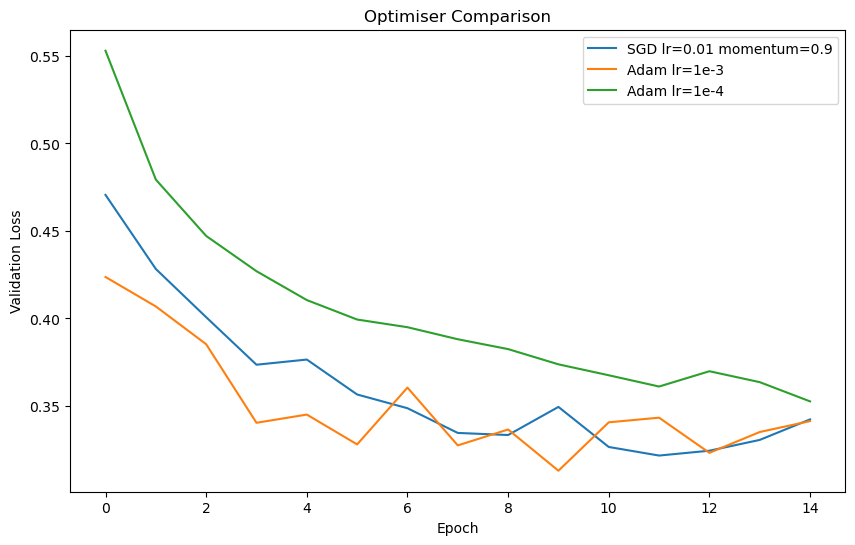

In [29]:
plt.figure(figsize=(10,6))

plt.plot(sgd_val_losses, label="SGD lr=0.01 momentum=0.9")

plt.plot(adam_val_losses, label="Adam lr=1e-3")

plt.plot(adam_small_val_losses, label="Adam lr=1e-4")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.title("Optimiser Comparison")

plt.legend()

plt.show()

In [30]:
print("SGD Final Val Accuracy:", sgd_val_accs[-1])

print("Adam 1e-3 Final Val Accuracy:", adam_val_accs[-1])

print("Adam 1e-4 Final Val Accuracy:", adam_small_val_accs[-1])

SGD Final Val Accuracy: 0.8743
Adam 1e-3 Final Val Accuracy: 0.8894
Adam 1e-4 Final Val Accuracy: 0.8729


Adam with lr=1e-3 converged the fastest during the first few epochs because adaptive optimisers adjust parameter updates automatically, allowing quicker progress early in training.

SGD with momentum improved more gradually but often produced a stable validation curve. Adam with lr=1e-4 learned much more slowly, showing that even with the same optimiser, the learning rate strongly affects convergence speed.

Comparing the two Adam runs demonstrates learning-rate sensitivity: 1e-3 trains efficiently, while 1e-4 may be too small, causing slower learning and higher validation loss after the same number of epochs. 